# CFL - reference-style training stats

Runs the Clustered Federated Learning example **in-process** (no `flwr run` needed): real PyTorch clients train on non-IID MNIST data while the `ClusteredFLStrategy` clusters them by their weight-update directions.

The plots below reproduce `display_train_stats` from the reference implementation (felisat/clustered-federated-learning): mean accuracy +/- std with split markers on the left, and the update norms with `eps_1` / `eps_2` threshold lines on the right.

**Set `NUM_CLIENTS = 10` and `NUM_ROUNDS = 50`** in the config cell below to reproduce the requested run. First run downloads MNIST once.

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

# Make the example's own modules importable regardless of the launch dir.
HERE = Path.cwd()
if (HERE / 'model.py').exists():
    sys.path.insert(0, str(HERE))
else:
    HERE = HERE / 'examples' / 'quickstart-cfl-pytorch'
    sys.path.insert(0, str(HERE))
print('example dir:', HERE)

## 1. Experiment setup

Clients are split into two ground-truth groups: clients `0..N/2-1` see digits **0-4**, clients `N/2..N-1` see digits **5-9**. CFL should discover these two clusters automatically. Thresholds are calibrated for this setup.

In [2]:
import types
import numpy as np
import matplotlib.pyplot as plt
from flwr.app import ArrayRecord, ConfigRecord

from mimosa._compat import arrayrecord_to_ndarrays, ndarrays_to_arrayrecord
from mimosa.server.cluster_manager import ClusterManager
from mimosa.server.registry import ClusterModelRegistry
from mimosa.strategy.cfl import ClusteredFLStrategy

import model as model_mod
import client as client_mod
from data import load_data

# ---- config: change these to reproduce a given run -------------------------
NUM_CLIENTS = 10      # number of simulated clients
NUM_ROUNDS  = 50      # number of federated rounds
BATCH_SIZE  = 32
LOCAL_EPOCHS = 1
LR          = 0.01
EPS_1, EPS_2 = 0.35, 0.45   # mean-norm stability / max-norm divergence
MIN_SPLIT_ROUND = 3      # earliest round a cluster may split (burn-in)
SAMPLES_PER_CLIENT = 2000  # per-client train samples; None = all (~20 min)
ROTATION_DEGREES = 90.0    # deterministic rotation noise (0 = no noise)
NOISE_SEED = 42
ROTATED_CLIENT_IDS = set(range(NUM_CLIENTS // 2))  # only first half get rotation
# ----------------------------------------------------------------------------

net = model_mod.Net()
initial_arrays = ArrayRecord(net.state_dict())
ndarrays = arrayrecord_to_ndarrays(initial_arrays)

cluster_manager = ClusterManager(
    eps_1=EPS_1, eps_2=EPS_2,
    min_cluster_size=3, max_tree_depth=3, min_split_round=MIN_SPLIT_ROUND)
registry = ClusterModelRegistry(initial_parameters=ndarrays)
strategy = ClusteredFLStrategy(
    ndarrays, cluster_manager, registry,
    eps_1=EPS_1, eps_2=EPS_2,
    min_cluster_size=3, max_tree_depth=3,
)
train_config = ConfigRecord({"lr": LR, "local-epochs": LOCAL_EPOCHS})
print('components ready: %d clients, %d rounds' % (NUM_CLIENTS, NUM_ROUNDS))


components ready: 10 clients, 10 rounds


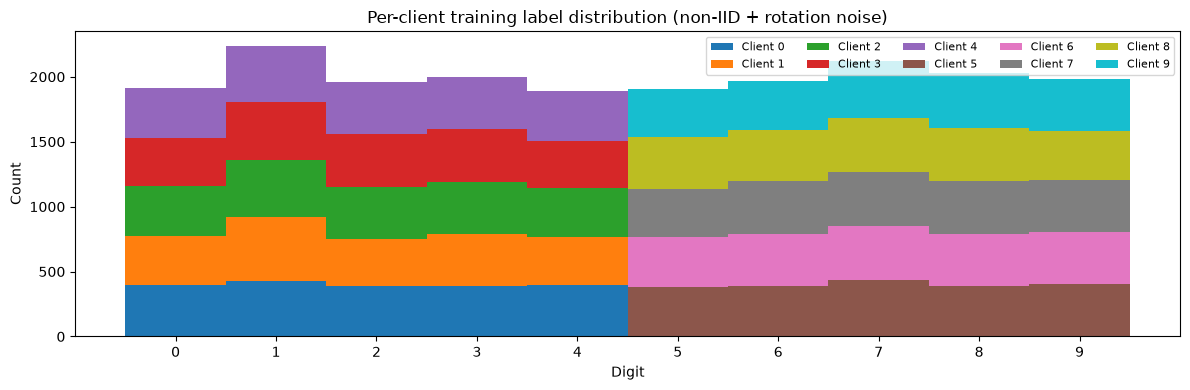

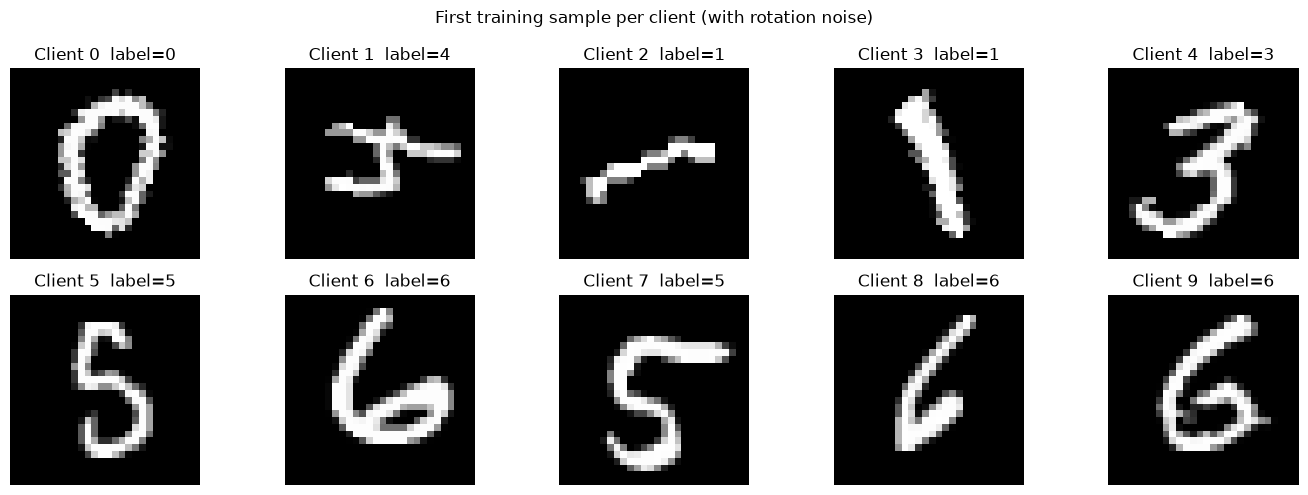

In [3]:
# ---- Per-client label distribution (training data) -------------------------
def _get_all_labels(loader):
    labels = []
    for _, y in loader:
        labels.extend(y.numpy().tolist())
    return np.array(labels)

client_label_lists = []
for nid in range(NUM_CLIENTS):
    trainloader, _ = load_data(
        nid, NUM_CLIENTS, BATCH_SIZE, SAMPLES_PER_CLIENT,
        ROTATION_DEGREES, NOISE_SEED,
        ROTATED_CLIENT_IDS,
    )
    client_label_lists.append(_get_all_labels(trainloader))

plt.figure(figsize=(12, 4))
plt.hist(
    client_label_lists, stacked=True,
    bins=np.arange(-0.5, 10.5, 1),
    label=[f'Client {i}' for i in range(NUM_CLIENTS)],
)
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.legend(ncol=5, fontsize=8, loc='upper right')
plt.title('Per-client training label distribution (non-IID + rotation noise)')
plt.tight_layout()
plt.show()

# ---- Sample images from each client ----------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for nid in range(NUM_CLIENTS):
    trainloader, _ = load_data(
        nid, NUM_CLIENTS, BATCH_SIZE, SAMPLES_PER_CLIENT,
        ROTATION_DEGREES, NOISE_SEED,
        ROTATED_CLIENT_IDS,
    )
    images, labels = next(iter(trainloader))
    ax = axes[nid // 5, nid % 5]
    ax.imshow(images[0].squeeze(), cmap='gray')
    ax.set_title(f'Client {nid}  label={labels[0].item()}')
    ax.axis('off')
plt.suptitle('First training sample per client (with rotation noise)')
plt.tight_layout()
plt.show()


## 2. In-process runner

Each round: `configure_train` routes every node its cluster's model, the PyTorch client trains on its non-IID partition and replies, `aggregate_train` computes server-side deltas and runs the split/aggregate decisions. An evaluate round then produces per-cluster accuracy.

In [4]:
class InProcessGrid:
    """Minimal Grid: exposes node ids; send/receive is driven manually."""
    def __init__(self, num_nodes):
        self._ids = list(range(num_nodes))
    def get_node_ids(self):
        return list(self._ids)


def _context(node_id, extra=None):
    cfg = {
        "batch-size": BATCH_SIZE,
        "local-epochs": LOCAL_EPOCHS,
        "samples-per-client": SAMPLES_PER_CLIENT,
        "rotation-degrees": ROTATION_DEGREES,
        "rotated-client-ids": ROTATED_CLIENT_IDS,
        "noise-seed": NOISE_SEED,
    }
    if extra:
        cfg.update(extra)
    return types.SimpleNamespace(
        node_config={"partition-id": node_id, "num-partitions": NUM_CLIENTS},
        run_config=cfg,
    )


def run_round(strategy, grid, round_no):
    """One train + evaluate round; returns the round's metrics dict."""
    msgs = strategy.configure_train(round_no, initial_arrays, train_config, grid)
    replies = [
        client_mod.train_round(m, _context(m.metadata.dst_node_id))
        for m in msgs
    ]
    strategy.aggregate_train(round_no, replies)

    emsgs = strategy.configure_evaluate(round_no, initial_arrays, ConfigRecord(), grid)
    ereplies = [
        client_mod.evaluate_round(m, _context(m.metadata.dst_node_id))
        for m in emsgs
    ]
    record = strategy.aggregate_evaluate(round_no, ereplies)
    if record is not None:
        strategy.history[-1]['per_cluster_accuracy'] = {
            key.split('.')[-1]: float(value)
            for key, value in record.items()
            if key.startswith('per_cluster_accuracy.')
        }
    return strategy.history[-1]


grid = InProcessGrid(NUM_CLIENTS)
print('runner ready')


runner ready


## 3. Run the experiment

Clusters start at 1 and are discovered dynamically. A split is allowed only after `min_split_round` burn-in rounds and when `mean_norm < eps_1` (cluster is stable) **and** `max_norm > eps_2` (cluster is still diverse). This matches the reference implementation.

In [5]:
print(f"{'round':>5} {'clusters':>8} {'max_norm':>10} {'sum_norm':>10} {'mean_norm':>10} splits")
print('-' * 64)
for r in range(1, NUM_ROUNDS + 1):
    m = run_round(strategy, grid, r)
    if r <= 5 or r % 10 == 0 or r == NUM_ROUNDS:
        print(f"{m['round']:>5} {m['num_clusters']:>8} {m['max_norm']:>10.4f} "
              f"{m['sum_norm']:>10.4f} {m['mean_norm']:>10.4f} {len(m['split_events']):>6}")

INFO :      configure_train: routed 10 node(s) across 1 active cluster(s)


round clusters   max_norm   sum_norm  mean_norm splits
----------------------------------------------------------------


INFO :      configure_train: routed 10 node(s) across 1 active cluster(s)


    1        1     0.6354     4.4657     0.4466      0


INFO :      configure_train: routed 10 node(s) across 1 active cluster(s)


...

INFO :      configure_train: routed 10 node(s) across 2 active cluster(s)


INFO :      configure_train: routed 10 node(s) across 2 active cluster(s)


INFO :      configure_train: routed 10 node(s) across 2 active cluster(s)


INFO :      configure_train: routed 10 node(s) across 2 active cluster(s)


   10        2     0.1836     1.0386     0.1039      0


In [6]:
# ---- FedAvg comparison runner --------------------------------------------
import torch

def _evaluate_per_client(model, device):
    per_client_acc = {}
    per_client_prec = {}
    for nid in range(NUM_CLIENTS):
        _, valloader = load_data(
            nid, NUM_CLIENTS, BATCH_SIZE, SAMPLES_PER_CLIENT,
            ROTATION_DEGREES, NOISE_SEED,
        ROTATED_CLIENT_IDS,
        )
        _, acc = client_mod.test(model, valloader, device)
        per_client_acc[nid] = acc

        # per-class precision for this client
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                preds = model(images).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        classes = sorted(set(all_labels))
        prec = {}
        for c in classes:
            tp = sum(1 for p, t in zip(all_preds, all_labels) if p == c and t == c)
            fp = sum(1 for p, t in zip(all_preds, all_labels) if p == c and t != c)
            prec[int(c)] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        per_client_prec[nid] = prec
    return per_client_acc, per_client_prec


def run_fedavg(num_rounds):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    global_model = model_mod.Net().to(device)
    lr = LR
    history = []
    for r in range(1, num_rounds + 1):
        global_state = {k: v.cpu().clone() for k, v in global_model.state_dict().items()}
        client_states = []
        for nid in range(NUM_CLIENTS):
            model = model_mod.Net().to(device)
            model.load_state_dict(global_state)
            trainloader, _ = load_data(
                nid, NUM_CLIENTS, BATCH_SIZE, SAMPLES_PER_CLIENT,
                ROTATION_DEGREES, NOISE_SEED,
        ROTATED_CLIENT_IDS,
            )
            client_mod.train(model, trainloader, LOCAL_EPOCHS, lr, device)
            client_states.append({k: v.cpu().clone() for k, v in model.state_dict().items()})

        # FedAvg: average all client weights
        avg_state = {}
        for key in global_state.keys():
            avg_state[key] = sum(client_states[i][key] for i in range(NUM_CLIENTS)) / NUM_CLIENTS
        global_model.load_state_dict(avg_state)

        per_client_acc, per_client_prec = _evaluate_per_client(global_model, device)
        history.append({
            'round': r,
            'per_client_accuracy': per_client_acc,
            'per_client_precision': per_client_prec,
            'mean_accuracy': float(np.mean(list(per_client_acc.values()))),
        })
        if r <= 5 or r % 5 == 0 or r == num_rounds:
            print(f"FedAvg round {r:>2}: mean_acc={history[-1]['mean_accuracy']:.4f}")
    return global_model, history


fedavg_model, fedavg_history = run_fedavg(NUM_ROUNDS)
print('FedAvg run complete')


FedAvg round  1: mean_acc=0.2575


FedAvg round  2: mean_acc=0.4225


FedAvg round  3: mean_acc=0.5475


FedAvg round  4: mean_acc=0.5975


FedAvg round  5: mean_acc=0.6250


FedAvg round 10: mean_acc=0.7075
FedAvg run complete


## 4. Final per-round metrics (JSON)

In [7]:
import json
print(json.dumps(strategy.history[-1], indent=2, sort_keys=True))

{
  "cluster_memberships": {
    "1": [
      "5",
      "6",
      "7",
      "8",
      "9"
    ],
    "2": [
      "0",
      "1",
      "2",
      "3",
      "4"
    ]
  },
  "max_norm": 0.18361608821968187,
  "mean_norm": 0.10385840156300716,
  "num_clusters": 2,
  "per_cluster_accuracy": {
    "1": 0.915,
    "2": 0.87
  },
  "round": 10,
  "split_events": [],
  "sum_norm": 1.0385840156300694
}


## 5. Reference-style plots (`display_train_stats`)

Left: mean per-cluster accuracy +/- std with black split lines and the final clusters annotated. Right: `||sum_i dW_i||` and `max_i ||dW_i||` with the `eps_1` (dashed) / `eps_2` (dotted) threshold lines.

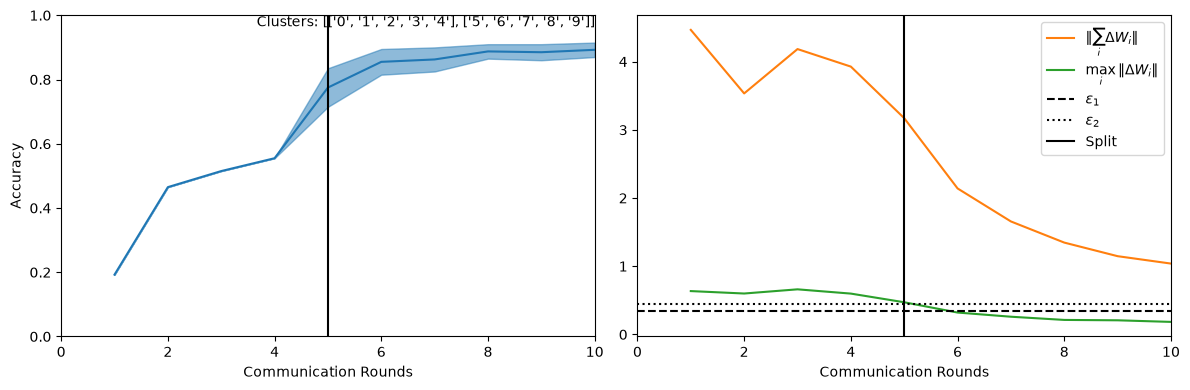

In [8]:
def plot_train_stats(history, eps_1, eps_2, communication_rounds):
    """Reproduces display_train_stats from felisat/clustered-federated-learning."""
    rounds = [e['round'] for e in history]
    split_rounds = [e['round'] for e in history if e.get('split_events')]

    fig = plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    acc_values = [list(e.get('per_cluster_accuracy', {}).values()) for e in history]
    acc_mean = np.array([float(np.mean(a)) if a else np.nan for a in acc_values])
    acc_std = np.array([float(np.std(a)) if a else 0.0 for a in acc_values])
    plt.fill_between(rounds, acc_mean - acc_std, acc_mean + acc_std, alpha=0.5, color='C0')
    plt.plot(rounds, acc_mean, color='C0')
    for s in split_rounds:
        plt.axvline(x=s, linestyle='-', color='k', label='Split')
    if history:
        memberships = history[-1].get('cluster_memberships', {})
        clusters = [sorted(m) for m in memberships.values()]
        clusters.sort(key=lambda m: m[0] if m else '')
        plt.text(x=communication_rounds, y=1, ha='right', va='top',
                 s='Clusters: {}'.format(clusters))
    plt.xlabel('Communication Rounds')
    plt.ylabel('Accuracy')
    plt.xlim(0, communication_rounds)
    plt.ylim(0, 1)

    plt.subplot(1, 2, 2)
    plt.plot(rounds, [e.get('sum_norm', 0.0) for e in history], color='C1',
             label=r'$\|\sum_i\Delta W_i \|$')
    plt.plot(rounds, [e.get('max_norm', 0.0) for e in history], color='C2',
             label=r'$\max_i\|\Delta W_i \|$')
    plt.axhline(y=eps_1, linestyle='--', color='k', label=r'$\varepsilon_1$')
    plt.axhline(y=eps_2, linestyle=':', color='k', label=r'$\varepsilon_2$')
    for s in split_rounds:
        plt.axvline(x=s, linestyle='-', color='k', label='Split')
    plt.xlabel('Communication Rounds')
    plt.legend()
    plt.xlim(0, communication_rounds)

    plt.tight_layout()
    plt.show()


plot_train_stats(strategy.history, EPS_1, EPS_2, NUM_ROUNDS)

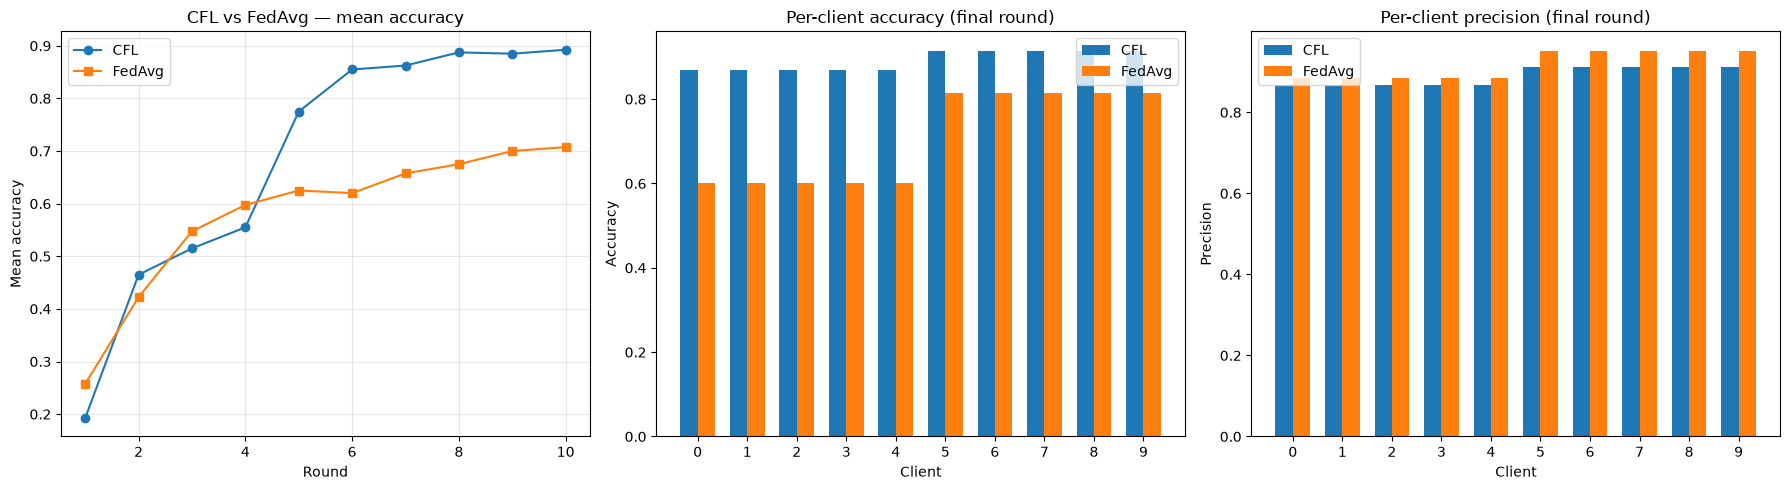


Per-client precision (final round):
------------------------------------------------------------


Client 0 (digits 0-4):
  CFL   precision: {0: 0.941, 1: 0.912, 2: 0.795, 3: 0.824, 4: 0.861}
  FedAvg precision: {0: 0.968, 1: 0.881, 2: 0.652, 3: 0.929, 4: 1.0}


Client 1 (digits 0-4):
  CFL   precision: {0: 0.941, 1: 0.912, 2: 0.795, 3: 0.824, 4: 0.861}
  FedAvg precision: {0: 0.968, 1: 0.881, 2: 0.652, 3: 0.929, 4: 1.0}


Client 2 (digits 0-4):
  CFL   precision: {0: 0.941, 1: 0.912, 2: 0.795, 3: 0.824, 4: 0.861}
  FedAvg precision: {0: 0.968, 1: 0.881, 2: 0.652, 3: 0.929, 4: 1.0}


Client 3 (digits 0-4):
  CFL   precision: {0: 0.941, 1: 0.912, 2: 0.795, 3: 0.824, 4: 0.861}
  FedAvg precision: {0: 0.968, 1: 0.881, 2: 0.652, 3: 0.929, 4: 1.0}


...

Client 5 (digits 5-9):
  CFL   precision: {5: 0.935, 6: 0.941, 7: 0.953, 8: 0.806, 9: 0.927}
  FedAvg precision: {5: 0.951, 6: 0.963, 7: 0.929, 8: 1.0, 9: 0.919}


Client 6 (digits 5-9):
  CFL   precision: {5: 0.935, 6: 0.941, 7: 0.953, 8: 0.806, 9: 0.927}
  FedAvg precision: {5: 0.951, 6: 0.963, 7: 0.929, 8: 1.0, 9: 0.919}


Client 7 (digits 5-9):
  CFL   precision: {5: 0.935, 6: 0.941, 7: 0.953, 8: 0.806, 9: 0.927}
  FedAvg precision: {5: 0.951, 6: 0.963, 7: 0.929, 8: 1.0, 9: 0.919}


Client 8 (digits 5-9):
  CFL   precision: {5: 0.935, 6: 0.941, 7: 0.953, 8: 0.806, 9: 0.927}
  FedAvg precision: {5: 0.951, 6: 0.963, 7: 0.929, 8: 1.0, 9: 0.919}


Client 9 (digits 5-9):
  CFL   precision: {5: 0.935, 6: 0.941, 7: 0.953, 8: 0.806, 9: 0.927}
  FedAvg precision: {5: 0.951, 6: 0.963, 7: 0.929, 8: 1.0, 9: 0.919}


In [9]:
# ---- CFL vs FedAvg comparison plots ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: mean accuracy over rounds
ax = axes[0]
cfl_mean_acc = [
    np.mean(list(h.get('per_cluster_accuracy', {}).values())) if h.get('per_cluster_accuracy') else np.nan
    for h in strategy.history
]
fedavg_mean_acc = [h['mean_accuracy'] for h in fedavg_history]
rounds = list(range(1, NUM_ROUNDS + 1))
ax.plot(rounds, cfl_mean_acc, marker='o', label='CFL')
ax.plot(rounds, fedavg_mean_acc, marker='s', label='FedAvg')
ax.set_xlabel('Round')
ax.set_ylabel('Mean accuracy')
ax.set_title('CFL vs FedAvg — mean accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Middle: per-client accuracy at final round
ax = axes[1]
x = np.arange(NUM_CLIENTS)
width = 0.35
cfl_final_acc = []
for nid in range(NUM_CLIENTS):
    cluster = strategy.cluster_manager.client_membership[str(nid)]
    cfl_final_acc.append(
        strategy.history[-1].get('per_cluster_accuracy', {}).get(str(cluster), 0.0)
    )
fedavg_final_acc = [fedavg_history[-1]['per_client_accuracy'][nid] for nid in range(NUM_CLIENTS)]
ax.bar(x - width/2, cfl_final_acc, width, label='CFL')
ax.bar(x + width/2, fedavg_final_acc, width, label='FedAvg')
ax.set_xlabel('Client')
ax.set_ylabel('Accuracy')
ax.set_title('Per-client accuracy (final round)')
ax.set_xticks(x)
ax.legend()

# Right: per-client precision at final round
ax = axes[2]
# Collect precision per client for CFL
cfl_final_prec = []
for nid in range(NUM_CLIENTS):
    cluster_id = strategy.cluster_manager.client_membership[str(nid)]
    cluster_params = strategy.cluster_model_registry.get_parameters(cluster_id)
    cfl_model = model_mod.Net()
    names = list(cfl_model.state_dict().keys())
    cfl_model.load_state_dict({n: torch.from_numpy(a) for n, a in zip(names, cluster_params)})
    _, cfl_prec_dict = _evaluate_per_client(cfl_model, torch.device("cpu"))
    # Use macro-average precision for this client
    client_prec = cfl_prec_dict[nid]
    cfl_final_prec.append(np.mean(list(client_prec.values())))

# FedAvg precision per client
fedavg_final_prec = []
for nid in range(NUM_CLIENTS):
    fa_prec = fedavg_history[-1]['per_client_precision'][nid]
    fedavg_final_prec.append(np.mean(list(fa_prec.values())))

ax.bar(x - width/2, cfl_final_prec, width, label='CFL')
ax.bar(x + width/2, fedavg_final_prec, width, label='FedAvg')
ax.set_xlabel('Client')
ax.set_ylabel('Precision')
ax.set_title('Per-client precision (final round)')
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

# ---- Per-client precision table (final round) -----------------------------
print("\nPer-client precision (final round):")
print("-" * 60)
for nid in range(NUM_CLIENTS):
    fa_prec = fedavg_history[-1]['per_client_precision'][nid]
    cluster_id = strategy.cluster_manager.client_membership[str(nid)]
    cluster_params = strategy.cluster_model_registry.get_parameters(cluster_id)
    cfl_model = model_mod.Net()
    names = list(cfl_model.state_dict().keys())
    cfl_model.load_state_dict({n: torch.from_numpy(a) for n, a in zip(names, cluster_params)})
    _, cfl_prec = _evaluate_per_client(cfl_model, torch.device("cpu"))
    cfl_prec = cfl_prec[nid]
    print(f"Client {nid} (digits {'0-4' if nid < NUM_CLIENTS//2 else '5-9'}):")
    print(f"  CFL   precision: { {k: round(v,3) for k,v in cfl_prec.items()} }")
    print(f"  FedAvg precision: { {k: round(v,3) for k,v in fa_prec.items()} }")


## 6. Cluster tree & ground-truth check

Ground truth: clients `0..N/2-1` (digits 0-4) vs `N/2..N-1` (digits 5-9). The learned clusters should match.

In [10]:
half = NUM_CLIENTS // 2
gt = {str(i): ('digits 0-4' if i < half else 'digits 5-9') for i in range(NUM_CLIENTS)}

print('Learned cluster memberships:')
for cid, cluster in sorted(strategy.cluster_manager.client_membership.items()):
    print(f'  client {cid} ({gt[cid]}): cluster {cluster}')

print('\nFinal active clusters:', strategy.cluster_model_registry.get_active())

print('\nCluster tree:')
tree = strategy.cluster_manager.dump_tree()
nodes = {n['id']: n for n in tree['nodes']}

def render(cid, prefix='', last=True):
    node = nodes[cid]
    label = f'Cluster {cid}' + (' (active)' if node['active'] else '')
    print(prefix + ('â””â”€â”€ ' if last else 'â”œâ”€â”€ ') + label)
    for i, k in enumerate(node['children']):
        render(k, prefix + ('    ' if last else 'â”‚   '), i == len(node['children']) - 1)

for n in tree['nodes']:
    if n['parent_id'] is None:
        print(f"Cluster {n['id']}")
        for i, k in enumerate(n['children']):
            render(k, '', i == len(n['children']) - 1)

Learned cluster memberships:
  client 0 (digits 0-4): cluster 2
  client 1 (digits 0-4): cluster 2
  client 2 (digits 0-4): cluster 2
  client 3 (digits 0-4): cluster 2
  client 4 (digits 0-4): cluster 2
  client 5 (digits 5-9): cluster 1
  client 6 (digits 5-9): cluster 1
  client 7 (digits 5-9): cluster 1
  client 8 (digits 5-9): cluster 1
  client 9 (digits 5-9): cluster 1

Final active clusters: [1, 2]

Cluster tree:
Cluster 0
â”œâ”€â”€ Cluster 1 (active)
â””â”€â”€ Cluster 2 (active)


## 7. Interpreting the results

- **Dynamic split**: `num_clusters` jumps from 1 â†’ 2 once the burn-in round is reached and the cluster is both stable (`mean_norm < eps_1`) and diverse (`max_norm > eps_2`).
- **Accuracy panel**: mean per-cluster accuracy rises and the std band narrows as each cluster converges on its own label group.
- **Norms panel**: after the split, `||sum_i dW_i||` drops (updates within each cluster align better) while `max_i||dW_i||` falls below `eps_2`, preventing further splits.
- **Tree**: two active leaves whose memberships match the ground-truth digit groups (no over-splitting into singletons).

The same experiment runs distributed via `flwr run` / `mimosa run`.